In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from math import sqrt
import matplotlib.pyplot as plt
import matplotlib.pyplot as pyplot
from matplotlib.collections import LineCollection
import xgboost as xgb
import statistics as stats
import statsmodels.api as sm
import shap
from xgboost import plot_importance, plot_tree, XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split, cross_val_score
from sklearn.inspection import PartialDependenceDisplay
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import linear_reset

# *Preprocessing* Data

In [ ]:
# Input Data
data = pd.read_csv('/content/(1) Skripsi_Fellita Odelia Wibowo.csv')
data

,Bulan,Suhu,DPM Rata-rata,DPM Maksimum,DPM Minimum
0,01 1999,24.177419,30092.61419,40613.36,9725.40
1,02 1999,23.971429,33898.16893,40363.34,8823.81
2,03 1999,24.280645,32010.34290,40334.69,1194.58
3,04 1999,24.133333,36139.28767,39600.00,19013.41
4,05 1999,23.590323,38292.59323,39589.61,27711.09
...,...,...,...,...,...
322,11 2025,24.950000,30137.76700,42921.25,10830.69
323,12 2025,24.935484,34640.83645,43361.31,6888.92
324,01 2026,24.474194,31986.48355,43070.62,9689.60
325,02 2026,24.553571,34299.91893,42413.89,10800.00


In [ ]:
# Menyiapkan Data
data = data.set_index('Bulan')
data.index = pd.to_datetime(data.index, format = 'mixed')

In [ ]:
# Menampilkan 5 Baris Pertama
print(data.head())

                 Suhu  DPM Rata-rata  DPM Maksimum  DPM Minimum
Bulan                                                          
1999-01-01  24.177419    30092.61419      40613.36      9725.40
1999-02-01  23.971429    33898.16893      40363.34      8823.81
1999-03-01  24.280645    32010.34290      40334.69      1194.58
1999-04-01  24.133333    36139.28767      39600.00     19013.41
1999-05-01  23.590323    38292.59323      39589.61     27711.09


In [ ]:
# Menampilkan Informasi Data
print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 327 entries, 1999-01-01 to 2026-03-01
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suhu           327 non-null    float64
 1   DPM Rata-rata  327 non-null    float64
 2   DPM Maksimum   327 non-null    float64
 3   DPM Minimum    327 non-null    float64
dtypes: float64(4)
memory usage: 12.8 KB
None


In [ ]:
# Mendefinisikan Variabel
Suhu = data['Suhu']
DPM_mean = data['DPM Rata-rata']
DPM_max = data['DPM Maksimum']
DPM_min = data['DPM Minimum']

In [ ]:
# Menyiapkan Data (DPM Rata-rata)
data_mean = data[['DPM Rata-rata']].copy()
print(data_mean.head())

            DPM Rata-rata
Bulan                    
1999-01-01    30092.61419
1999-02-01    33898.16893
1999-03-01    32010.34290
1999-04-01    36139.28767
1999-05-01    38292.59323


In [ ]:
# Menyiapkan Data (DPM Maksimum)
data_max = data[['DPM Maksimum']].copy()
print(data_max.head())

            DPM Maksimum
Bulan                   
1999-01-01      40613.36
1999-02-01      40363.34
1999-03-01      40334.69
1999-04-01      39600.00
1999-05-01      39589.61


In [ ]:
# Menyiapkan Data (DPM Minimum)
data_min = data[['DPM Minimum']].copy()
print(data_min.head())

            DPM Minimum
Bulan                  
1999-01-01      9725.40
1999-02-01      8823.81
1999-03-01      1194.58
1999-04-01     19013.41
1999-05-01     27711.09


# DPM Rata-rata

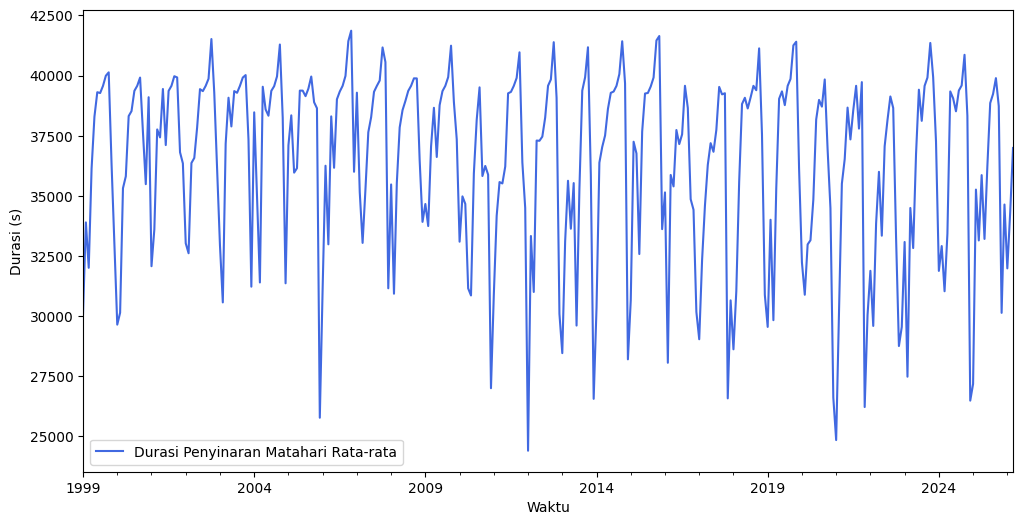

In [ ]:
# Plot Data Durasi Penyinaran Matahari Rata-rata
plot_DPM_mean = DPM_mean.plot(style = '-', figsize = (12, 6), color = 'royalblue', label = 'Durasi Penyinaran Matahari Rata-rata')
plot_DPM_mean.set_xlabel("Waktu")
plot_DPM_mean.set_ylabel("Durasi (s)")
plot_DPM_mean.legend()

In [ ]:
# Fitur Time Series
def create_features(data, target, lag_features, rolling_windows):
    # Salinan DataFrame (menghindari modifikasi data asli)
    data_features = data.copy()
    # Date-Time
    data_features['month'] = data_features.index.month
    data_features['year'] = data_features.index.year
    # Lag Features (berbasis bulanan)
    for lag in lag_features:
        data_features[f'{target}_lag_{lag}'] = data_features[target].shift(lag)
    # Rolling Windows
    for col in data.columns:
        for window in rolling_windows:
            data_features[f'{col}_mean_{window}'] = (data_features[col].rolling(window = window).mean())
            data_features[f'{col}_std_{window}'] = (data_features[col].rolling(window = window).std())
    # Cyclical Encoding untuk (pola bulanan)
    data_features['month_sin'] = np.sin(2 * np.pi * data_features['month']/12)
    data_features['month_cos'] = np.cos(2 * np.pi * data_features['month']/12)

    # Hapus baris dengan nilai NaN (yang dihasilkan dari shift dan rolling)
    data_features.dropna(inplace = True)

    return data_features

In [ ]:
# Mendefinisikan Fitur
lag_features = [6, 12, 24]
rolling_windows = [6, 12, 24]

In [ ]:
# Parameter Terbaik
best_params_mean = {
    "max_depth": 3,
    "learning_rate": 0.03,
    "n_estimators": 200,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "min_child_weight": 12,
    "gamma": 0,
    "reg_alpha": 15,
    "reg_lambda": 10
    }

In [ ]:
# Menjalankan Fungsi Feature Engineering (Full Data)
all_mean_processed = create_features(
    data_mean,
    'DPM Rata-rata',
    lag_features,
    rolling_windows
)
all_mean_processed.shape

(303, 14)

In [ ]:
# Split Data Hasil Feature Engineering X & y
X_mean = all_mean_processed.drop('DPM Rata-rata', axis = 1)
y_mean = all_mean_processed['DPM Rata-rata']
print(f"X: {X_mean.shape}, y: {y_mean.shape}")

X: (303, 13), y: (303,)


In [ ]:
# Model Data dengan Parameter Terbaik
final_model_mean = xgb.XGBRegressor(**best_params_mean, n_jobs = -1, objective = 'reg:squarederror')
final_model_mean.fit(X_mean, y_mean)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=12, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Membuat Prediksi pada Data
y_pred_mean = final_model_mean.predict(X_mean)

In [ ]:
# Feature Importance dari Model
importance_mean = final_model_mean.feature_importances_
feature_names_mean = X_mean.columns

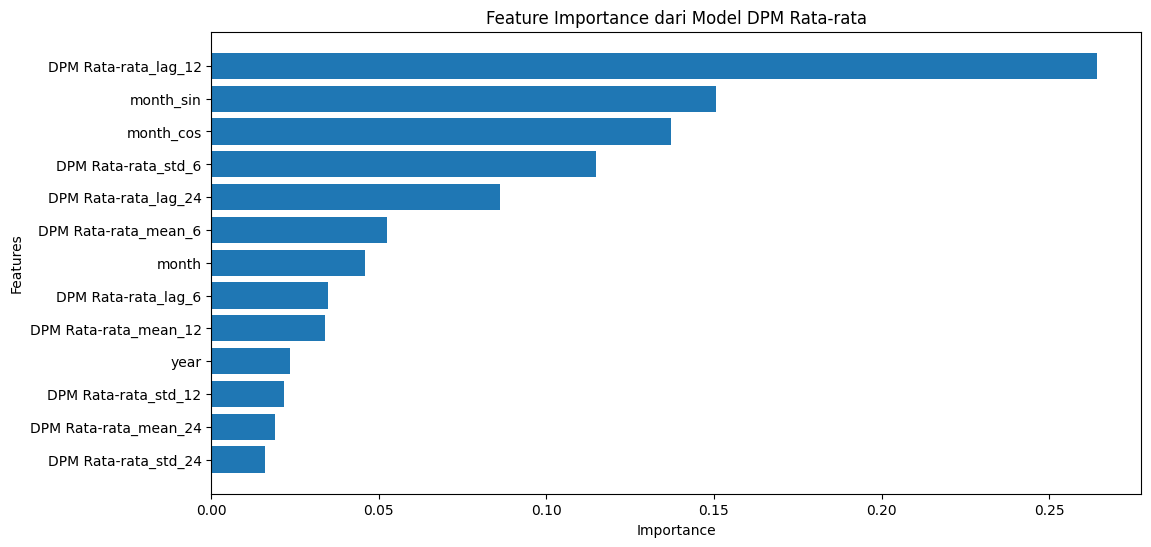

In [ ]:
# Visualisasi Feature Importance dari Model
feature_importance_data_mean = pd.DataFrame({
    'feature': feature_names_mean,
    'importance': importance_mean
})

feature_importance_data_mean = feature_importance_data_mean.sort_values(by = 'importance', ascending = False)

plt.figure(figsize = (12, 6))
plt.barh(feature_importance_data_mean['feature'], feature_importance_data_mean['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance dari Model DPM Rata-rata')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Fungsi MAPE
def mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    ape = np.abs((y_true - y_pred) / y_true)

    mape = np.mean(ape) * 100

    return mape

In [ ]:
# Evaluasi
mse_mean = mean_squared_error(y_mean, y_pred_mean)
rmse_mean = np.sqrt(mse_mean)
mape_mean = mean_absolute_percentage_error(y_mean, y_pred_mean)

print("Evaluasi:")
print(f"MSE: {mse_mean:.3f}")
print(f"RMSE: {rmse_mean:.3f}")
print(f"MAPE: {mape_mean:.3f}%")

Evaluasi:
MSE: 2114607.089
RMSE: 1454.169
MAPE: 3.013%


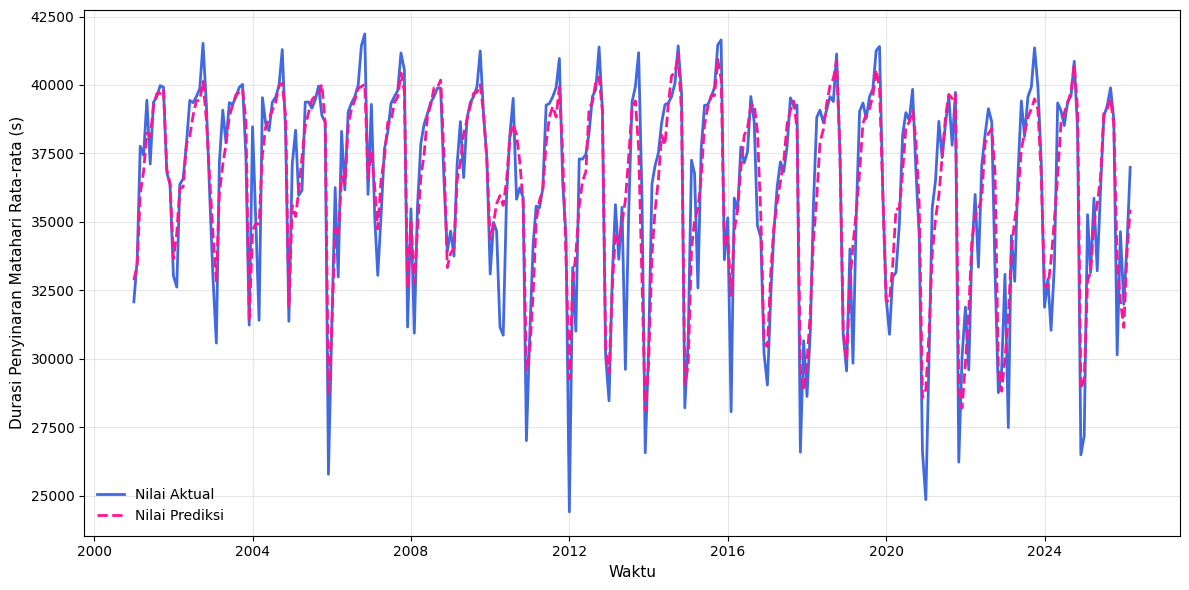

In [ ]:
# Visualisasi Data Aktual vs Prediksi
hasil_mean = pd.DataFrame({
    'aktual': y_mean,
    'prediksi': y_pred_mean
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil_mean.index,
    hasil_mean['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil_mean.index,
    hasil_mean['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Durasi Penyinaran Matahari Rata-rata (s)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

In [ ]:
# Data Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual_mean, prediksi_mean in zip(y_mean, y_pred_mean):
    selisih_mean = aktual_mean - prediksi_mean
    print(f"  {aktual_mean:.3f}         {prediksi_mean:.3f}            {selisih_mean:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  32076.907         32870.762            -793.855
  33610.048         33429.961            180.086
  37763.247         36029.059            1734.188
  37431.329         36844.250            587.078
  39444.251         38244.172            1200.078
  37112.793         38101.586            -988.793
  39365.385         39207.301            158.086
  39575.669         39687.891            -112.223
  39975.193         39693.746            281.445
  39923.471         39840.605            82.863
  36814.700         36908.949            -94.250
  36352.766         36402.145            -49.379
  33030.051         33651.711            -621.660
  32616.551         34586.582            -1970.031
  36367.262         36214.480            152.781
  36577.674         36277.855            299.820
  37850.685         37845.105            5.578
  39437.745         38127.328            1310.418
  39355.194         38879.000 

In [ ]:
# Fungsi untuk Peramalan
def quick_forecast_future(model, X_features, all_processed_data, target_name, n_months):

    predictions = []
    historical_features = X_features.columns.tolist()

    current_data = all_processed_data.copy()

    all_values = current_data[target_name].tolist()

    print(f"Data historis tersedia: {len(all_values)} bulan")
    print(f"Data terakhir: {all_values[-1]:.3f}")

    last_date = current_data.index[-1]
    forecast_dates = pd.date_range(
        start = last_date + pd.DateOffset(months = 1),
        periods = n_months,
        freq = 'MS'
    )

    print(f"Forecast periode: {forecast_dates[0].strftime('%B %Y')} - {forecast_dates[-1].strftime('%B %Y')}")

    for i in range(n_months):

        input_features = pd.DataFrame()

        forecast_date = forecast_dates[i]
        month = forecast_date.month
        year = forecast_date.year

        if 'year' in historical_features:
            input_features['year'] = [year]

        if 'month' in historical_features:
            input_features['month'] = [month]

        for lag in lag_features:
            col_name = f'{target_name}_lag_{lag}'
            if col_name in historical_features:
                if len(all_values) >= lag:
                    input_features[col_name] = [all_values[-lag]]
                else:
                    input_features[col_name] = [np.nan]

        for window in rolling_windows:
            col_name = f'{target_name}_mean_{window}'
            if col_name in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name] = [temp_df[target_name].iloc[-window:].mean()]
                else:
                    input_features[col_name] = [np.nan]

            col_name_std = f'{target_name}_std_{window}'
            if col_name_std in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name_std] = [temp_df[target_name].iloc[-window:].std()]
                else:
                    input_features[col_name_std] = [np.nan]

        input_features['month_sin'] = [np.sin(2 * np.pi * month / 12)]
        input_features['month_cos'] = [np.cos(2 * np.pi * month / 12)]

        for col in historical_features:
            if col not in input_features.columns:

                input_features[col] = [X_features[col].mean()]

        input_features = input_features[historical_features]

        pred = model.predict(input_features)[0]
        predictions.append(pred)

        all_values.append(pred)

    return predictions, forecast_dates

In [ ]:
# Melakukan Forecasting
pred_mean_future, dates_mean = quick_forecast_future(
        final_model_mean,
        X_mean,
        all_mean_processed,
        'DPM Rata-rata',
        n_months = 9
    )
for date, pred in zip(dates_mean, pred_mean_future):
        print(f"  {date.strftime('%B %Y')}: {pred:.3f}")

Data historis tersedia: 303 bulan
Data terakhir: 36992.689
Forecast periode: April 2026 - December 2026
  April 2026: 36409.082
  May 2026: 37328.203
  June 2026: 38158.410
  July 2026: 38807.402
  August 2026: 39187.352
  September 2026: 39407.031
  October 2026: 39360.770
  November 2026: 36900.164
  December 2026: 35442.367


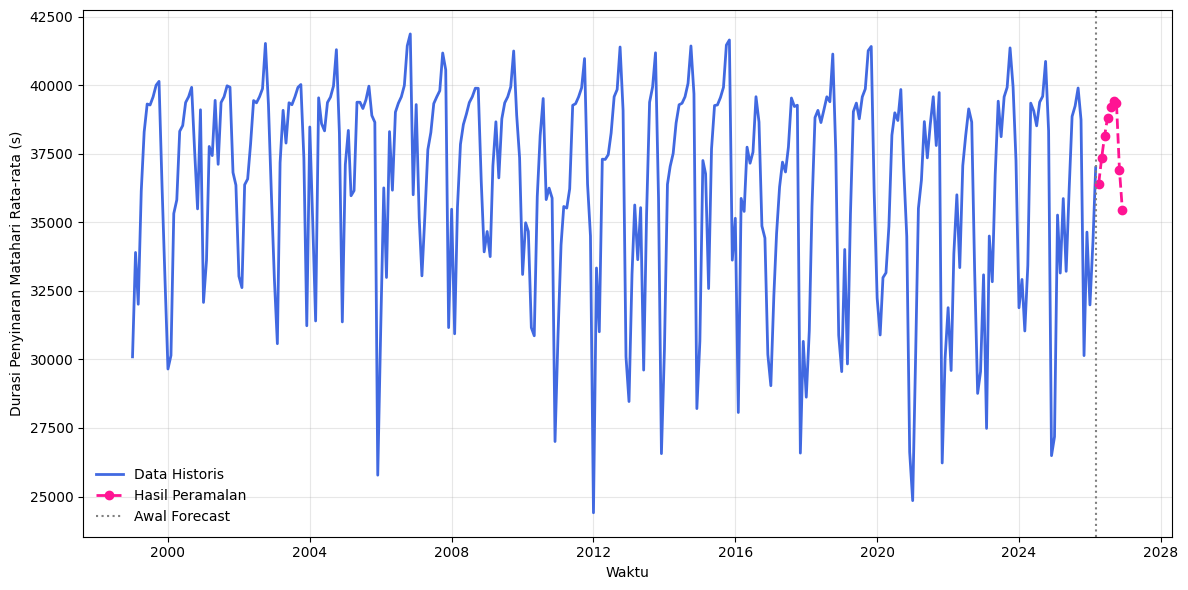

In [ ]:
# Visualisasi Hasil Peramalan
forecast_mean = pd.DataFrame({
    'tanggal': dates_mean,
    'prediksi': pred_mean_future
})
forecast_mean.set_index('tanggal', inplace = True)

historical_data_mean = data_mean[['DPM Rata-rata']].copy()
combined_mean = pd.concat([historical_data_mean, forecast_mean.rename(columns = {'prediksi': 'DPM Rata-rata'})])

plt.figure(figsize = (12, 6))

plt.plot(
    historical_data_mean.index,
    historical_data_mean['DPM Rata-rata'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_mean.index,
    forecast_mean['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.axvline(
    x = historical_data_mean.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Rata-rata (s)')

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

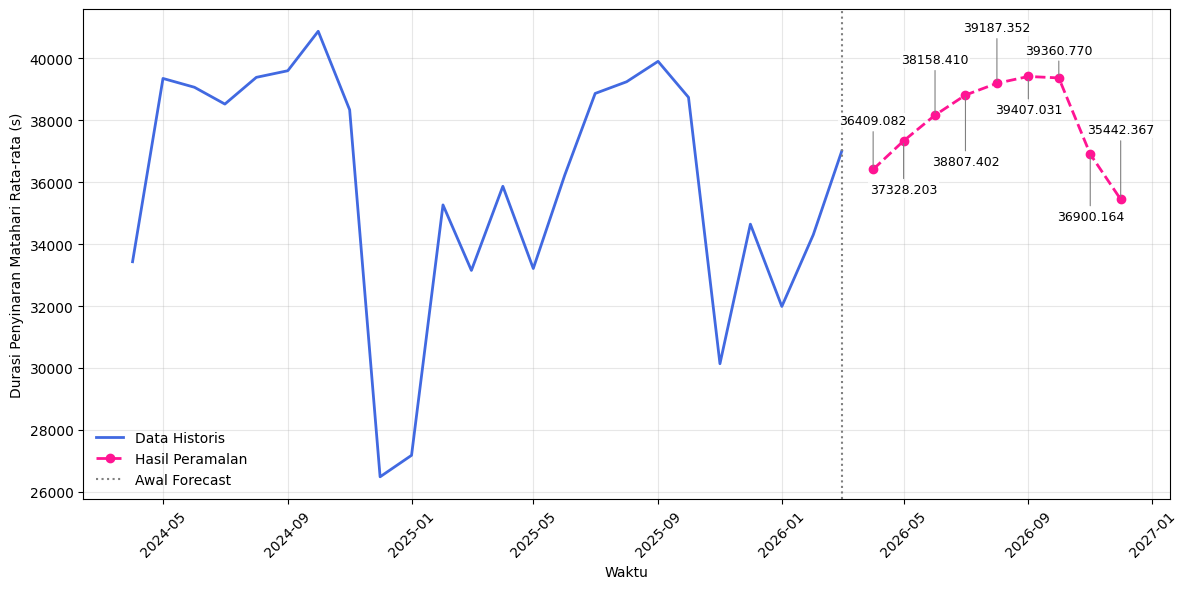

In [ ]:
# Visualisasi Hasil Peramalan
historical_tail_mean = data_mean[['DPM Rata-rata']].tail(24).copy()

forecast_mean = pd.DataFrame({
    'tanggal': dates_mean,
    'prediksi': pred_mean_future
})
forecast_mean.set_index('tanggal', inplace = True)

plt.figure(figsize = (12, 6))

plt.plot(
    historical_tail_mean.index,
    historical_tail_mean['DPM Rata-rata'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_mean.index,
    forecast_mean['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.axvline(
    x = historical_tail_mean.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

offsets = [
    (0, 35),
    (0, -35),
    (0, 40),
    (0, -48),
    (0, 40),
    (0, -24),
    (0, 20),
    (0, -45),
    (0, 50)
]

for (x, y), (dx, dy) in zip(zip(forecast_mean.index, forecast_mean['prediksi']), offsets):
    plt.annotate(
        f'{y:.3f}',
        xy = (x, y),
        xytext = (dx, dy),
        textcoords = 'offset points',
        ha = 'center',
        va = 'center',
        fontsize = 9,
        bbox = dict(facecolor = 'white', alpha = 0.85, edgecolor = 'none', pad = 1.2),
        arrowprops = dict(
            arrowstyle = '-',
            color = 'gray',
            lw = 0.8
        )
    )

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Rata-rata (s)')
plt.xticks(rotation = 45)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

# DPM Maksimum

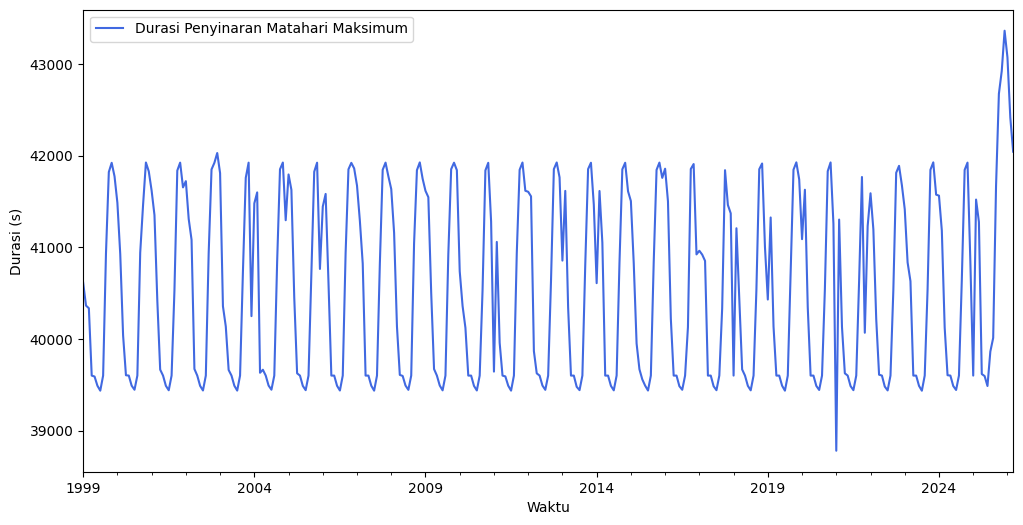

In [ ]:
# Plot Data Durasi Penyinaran Matahari Maksimum
plot_DPM_max = DPM_max.plot(style = '-', figsize = (12, 6), color = 'royalblue', label = 'Durasi Penyinaran Matahari Maksimum')
plot_DPM_max.set_xlabel("Waktu")
plot_DPM_max.set_ylabel("Durasi (s)")
plot_DPM_max.legend()

In [ ]:
# Fitur Time Series
def create_features(data, target, lag_features, rolling_windows):
    # Salinan DataFrame (menghindari modifikasi data asli)
    data_features = data.copy()
    # Date-Time
    data_features['month'] = data_features.index.month
    data_features['year'] = data_features.index.year
    # Lag Features (berbasis bulanan)
    for lag in lag_features:
        data_features[f'{target}_lag_{lag}'] = data_features[target].shift(lag)
    # Rolling Windows
    for col in data.columns:
        for window in rolling_windows:
            data_features[f'{col}_mean_{window}'] = (data_features[col].rolling(window = window).mean())
            data_features[f'{col}_std_{window}'] = (data_features[col].rolling(window = window).std())
    # Cyclical Encoding untuk (pola bulanan)
    data_features['month_sin'] = np.sin(2 * np.pi * data_features['month']/12)
    data_features['month_cos'] = np.cos(2 * np.pi * data_features['month']/12)

    # Hapus baris dengan nilai NaN (yang dihasilkan dari shift dan rolling)
    data_features.dropna(inplace = True)

    return data_features

In [ ]:
# Mendefinisikan Fitur
lag_features = [6, 12, 24]
rolling_windows = [6, 12, 24]

In [ ]:
# Parameter Terbaik
best_params_max = {
    "max_depth": 4,
    "learning_rate": 0.02,
    "n_estimators": 200,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "min_child_weight": 10,
    "gamma": 0,
    "reg_alpha": 5,
    "reg_lambda": 7
    }

In [ ]:
# Menjalankan Fungsi Feature Engineering (Full Data)
all_max_processed = create_features(
    data_max,
    'DPM Maksimum',
    lag_features,
    rolling_windows
)
all_max_processed.shape

(303, 14)

In [ ]:
# Split Data Hasil Feature Engineering X & y
X_max = all_max_processed.drop('DPM Maksimum', axis = 1)
y_max = all_max_processed['DPM Maksimum']
print(f"X: {X_max.shape}, y: {y_max.shape}")

X: (303, 13), y: (303,)


In [ ]:
# Model Data dengan Parameter Terbaik
final_model_max = xgb.XGBRegressor(**best_params_max, n_jobs = -1, objective = 'reg:squarederror')
final_model_max.fit(X_max, y_max)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Membuat Prediksi pada Data
y_pred_max = final_model_max.predict(X_max)

In [ ]:
# Feature Importance dari Model
importance_max = final_model_max.feature_importances_
feature_names_max = X_max.columns

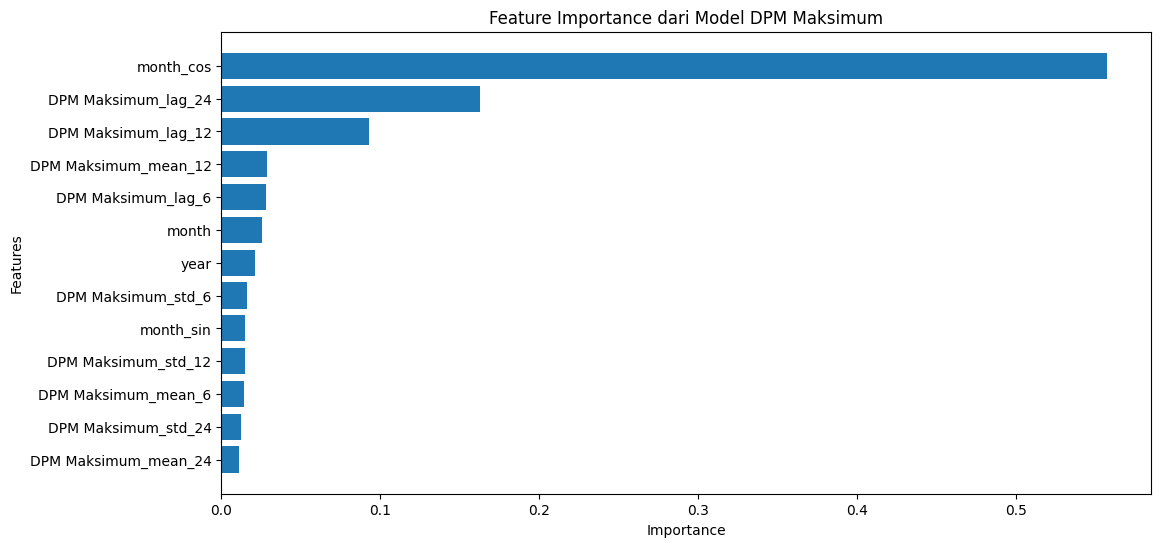

In [ ]:
# Visualisasi Feature Importance dari Model
feature_importance_data_max = pd.DataFrame({
    'feature': feature_names_max,
    'importance': importance_max
})

feature_importance_data_max = feature_importance_data_max.sort_values(by = 'importance', ascending = False)

plt.figure(figsize = (12, 6))
plt.barh(feature_importance_data_max['feature'], feature_importance_data_max['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance dari Model DPM Maksimum')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Fungsi MAPE
def mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    ape = np.abs((y_true - y_pred) / y_true)

    mape = np.mean(ape) * 100

    return mape

In [ ]:
# Evaluasi
mse_max = mean_squared_error(y_max, y_pred_max)
rmse_max = np.sqrt(mse_max)
mape_max = mean_absolute_percentage_error(y_max, y_pred_max)

print("Evaluasi:")
print(f"MSE: {mse_max:.3f}")
print(f"RMSE: {rmse_max:.3f}")
print(f"MAPE: {mape_max:.3f}%")

Evaluasi:
MSE: 65457.310
RMSE: 255.846
MAPE: 0.356%


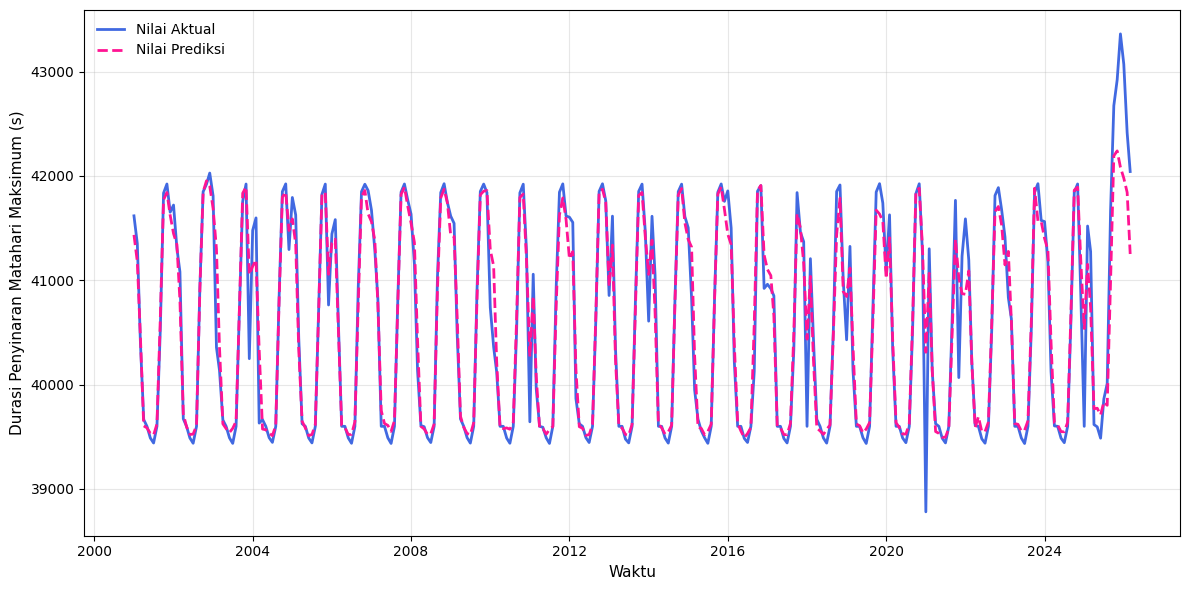

In [ ]:
# Visualisasi Data Aktual vs Prediksi
hasil_max = pd.DataFrame({
    'aktual': y_max,
    'prediksi': y_pred_max
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil_max.index,
    hasil_max['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil_max.index,
    hasil_max['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Durasi Penyinaran Matahari Maksimum (s)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

In [ ]:
# Data Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual_max, prediksi_max in zip(y_max, y_pred_max):
    selisih_max = aktual_max - prediksi_max
    print(f"  {aktual_max:.3f}         {prediksi_max:.3f}            {selisih_max:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  41617.500         41434.980            182.520
  41350.230         41177.016            173.215
  40416.040         40470.586            -54.547
  39665.160         39604.379            60.781
  39600.000         39585.055            14.945
  39488.300         39532.812            -44.512
  39440.020         39515.914            -75.895
  39600.000         39622.285            -22.285
  40527.120         40637.570            -110.449
  41835.970         41771.492            64.477
  41922.620         41840.508            82.113
  41652.810         41623.793            29.016
  41720.650         41447.609            273.039
  41308.200         41342.879            -34.680
  41080.890         40805.027            275.863
  39672.180         39719.242            -47.062
  39600.000         39596.512            3.488
  39488.040         39521.434            -33.395
  39437.700         39525.504            -

In [ ]:
# Fungsi untuk Peramalan
def quick_forecast_future(model, X_features, all_processed_data, target_name, n_months):

    predictions = []
    historical_features = X_features.columns.tolist()

    current_data = all_processed_data.copy()

    all_values = current_data[target_name].tolist()

    print(f"Data historis tersedia: {len(all_values)} bulan")
    print(f"Data terakhir: {all_values[-1]:.3f}")

    last_date = current_data.index[-1]
    forecast_dates = pd.date_range(
        start = last_date + pd.DateOffset(months = 1),
        periods = n_months,
        freq = 'MS'
    )

    print(f"Forecast periode: {forecast_dates[0].strftime('%B %Y')} - {forecast_dates[-1].strftime('%B %Y')}")

    for i in range(n_months):

        input_features = pd.DataFrame()

        forecast_date = forecast_dates[i]
        month = forecast_date.month
        year = forecast_date.year

        if 'year' in historical_features:
            input_features['year'] = [year]

        if 'month' in historical_features:
            input_features['month'] = [month]

        for lag in lag_features:
            col_name = f'{target_name}_lag_{lag}'
            if col_name in historical_features:
                if len(all_values) >= lag:
                    input_features[col_name] = [all_values[-lag]]
                else:
                    input_features[col_name] = [np.nan]

        for window in rolling_windows:
            col_name = f'{target_name}_mean_{window}'
            if col_name in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name] = [temp_df[target_name].iloc[-window:].mean()]
                else:
                    input_features[col_name] = [np.nan]

            col_name_std = f'{target_name}_std_{window}'
            if col_name_std in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name_std] = [temp_df[target_name].iloc[-window:].std()]
                else:
                    input_features[col_name_std] = [np.nan]

        input_features['month_sin'] = [np.sin(2 * np.pi * month / 12)]
        input_features['month_cos'] = [np.cos(2 * np.pi * month / 12)]

        for col in historical_features:
            if col not in input_features.columns:

                input_features[col] = [X_features[col].mean()]

        input_features = input_features[historical_features]

        pred = model.predict(input_features)[0]
        predictions.append(pred)

        all_values.append(pred)

    return predictions, forecast_dates

In [ ]:
# Melakukan Forecasting
pred_max_future, dates_max = quick_forecast_future(
        final_model_max,
        X_max,
        all_max_processed,
        'DPM Maksimum',
        n_months = 9
    )
for date, pred in zip(dates_max, pred_max_future):
        print(f"  {date.strftime('%B %Y')}: {pred:.3f}")

Data historis tersedia: 303 bulan
Data terakhir: 42042.050
Forecast periode: April 2026 - December 2026
  April 2026: 40162.660
  May 2026: 40140.383
  June 2026: 40121.953
  July 2026: 40111.316
  August 2026: 40023.516
  September 2026: 41305.148
  October 2026: 41894.172
  November 2026: 41941.258
  December 2026: 41902.547


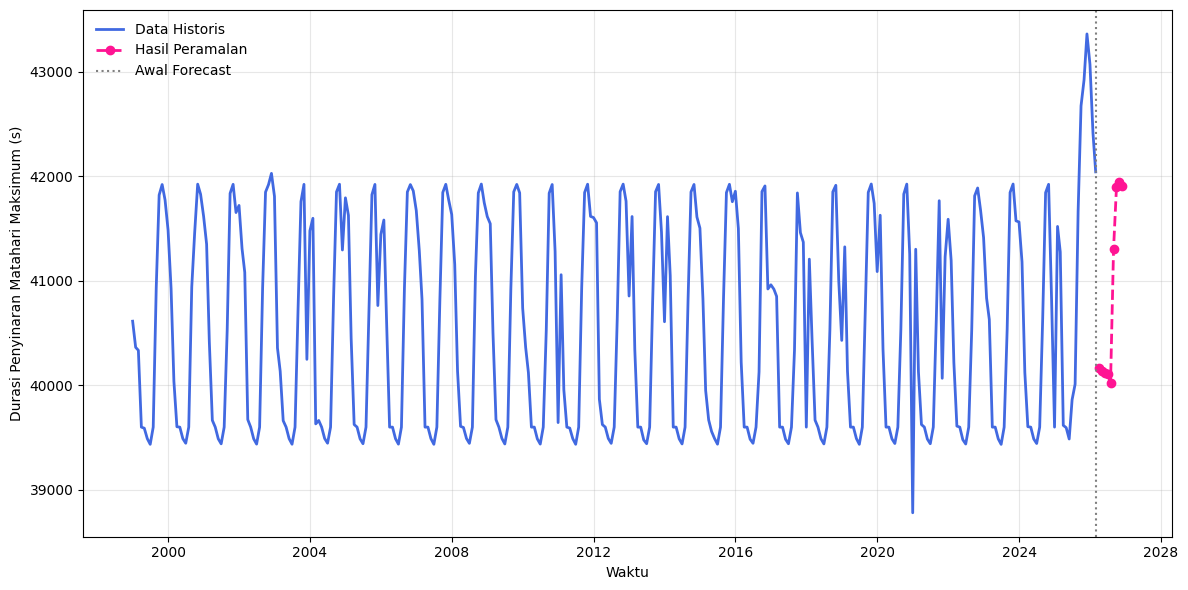

In [ ]:
# Visualisasi Hasil Peramalan
forecast_max = pd.DataFrame({
    'tanggal': dates_max,
    'prediksi': pred_max_future
})
forecast_max.set_index('tanggal', inplace = True)

historical_data_max = data_max[['DPM Maksimum']].copy()
combined_max = pd.concat([historical_data_max, forecast_max.rename(columns = {'prediksi': 'DPM Maksimum'})])

plt.figure(figsize = (12, 6))

plt.plot(
    historical_data_max.index,
    historical_data_max['DPM Maksimum'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_max.index,
    forecast_max['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.axvline(
    x = historical_data_max.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Maksimum (s)')

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

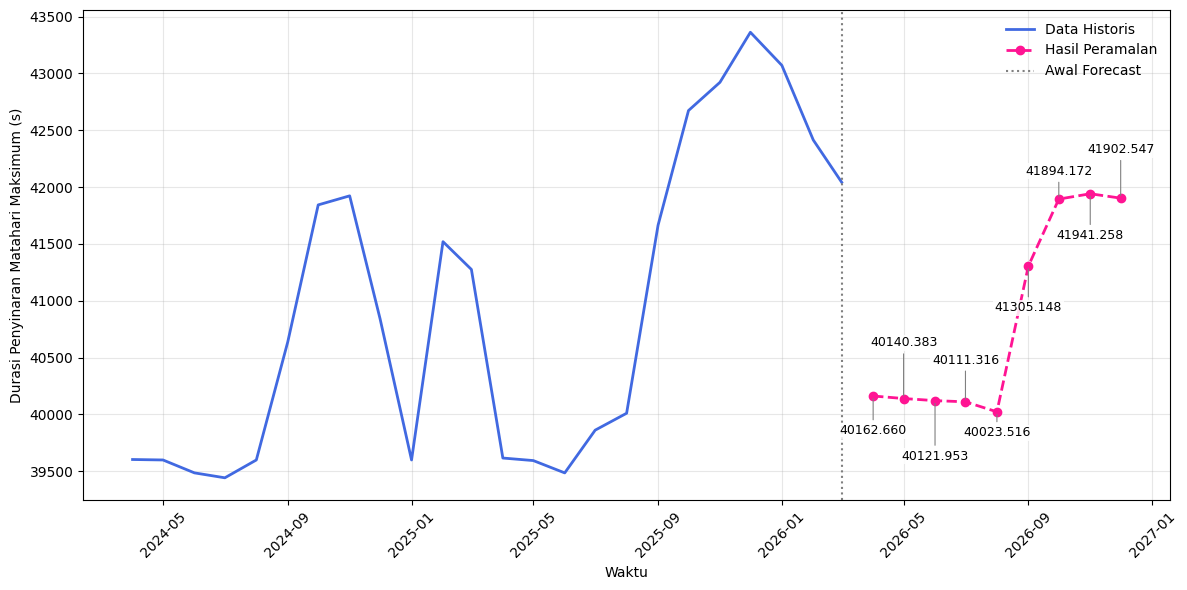

In [ ]:
# Visualisasi Hasil Peramalan
historical_tail_max = data_max[['DPM Maksimum']].tail(24).copy()

forecast_max = pd.DataFrame({
    'tanggal': dates_max,
    'prediksi': pred_max_future
})
forecast_max.set_index('tanggal', inplace = True)

plt.figure(figsize = (12, 6))

plt.plot(
    historical_tail_max.index,
    historical_tail_max['DPM Maksimum'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_max.index,
    forecast_max['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.axvline(
    x = historical_tail_max.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

offsets = [
    (0, -25),
    (0, 40),
    (0, -40),
    (0, 30),
    (0, -15),
    (0, -30),
    (0, 20),
    (0, -30),
    (0, 35)
]

for (x, y), (dx, dy) in zip(zip(forecast_max.index, forecast_max['prediksi']), offsets):
    plt.annotate(
        f'{y:.3f}',
        xy = (x, y),
        xytext = (dx, dy),
        textcoords = 'offset points',
        ha = 'center',
        va = 'center',
        fontsize = 9,
        bbox = dict(facecolor = 'white', alpha = 0.85, edgecolor = 'none', pad = 1.2),
        arrowprops = dict(
            arrowstyle = '-',
            color = 'gray',
            lw = 0.8
        )
    )

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Maksimum (s)')
plt.xticks(rotation = 45)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

# DPM Minimum

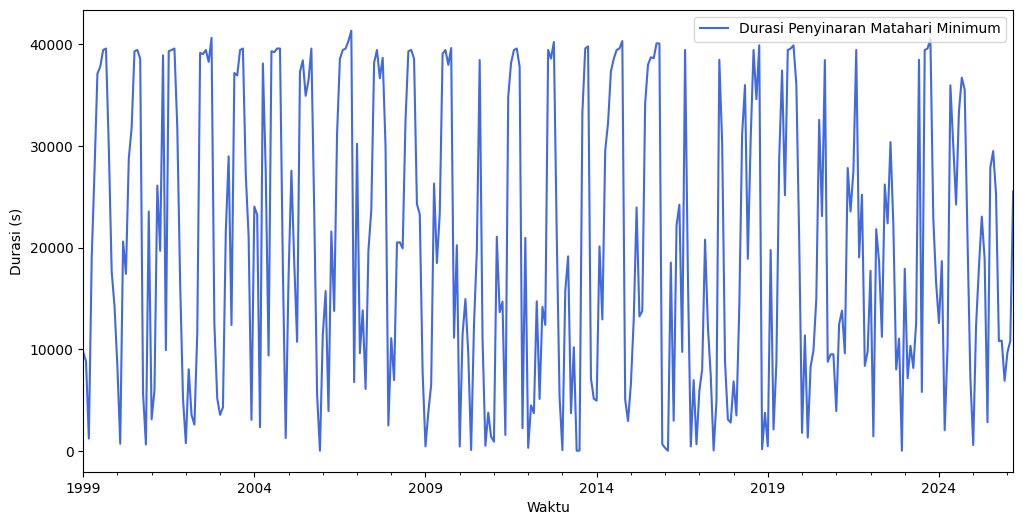

In [ ]:
# Plot Data Durasi Penyinaran Matahari Minimum
plot_DPM_min = DPM_min.plot(style = '-', figsize = (12, 6), color = 'royalblue', label = 'Durasi Penyinaran Matahari Minimum')
plot_DPM_min.set_xlabel("Waktu")
plot_DPM_min.set_ylabel("Durasi (s)")
plot_DPM_min.legend()

In [ ]:
# Fitur Time Series
def create_features(data, target, lag_features, rolling_windows):
    # Salinan DataFrame (menghindari modifikasi data asli)
    data_features = data.copy()
    # Date-Time
    data_features['month'] = data_features.index.month
    data_features['year'] = data_features.index.year
    # Lag Features (berbasis bulanan)
    for lag in lag_features:
        data_features[f'{target}_lag_{lag}'] = data_features[target].shift(lag)
    # Rolling Windows
    for col in data.columns:
        for window in rolling_windows:
            data_features[f'{col}_mean_{window}'] = (data_features[col].rolling(window = window).mean())
            data_features[f'{col}_std_{window}'] = (data_features[col].rolling(window = window).std())
    # Cyclical Encoding untuk (pola bulanan)
    data_features['month_sin'] = np.sin(2 * np.pi * data_features['month']/12)
    data_features['month_cos'] = np.cos(2 * np.pi * data_features['month']/12)

    # Hapus baris dengan nilai NaN (yang dihasilkan dari shift dan rolling)
    data_features.dropna(inplace = True)

    return data_features

In [ ]:
# Mendefinisikan Fitur
lag_features = [3, 6, 12]
rolling_windows = [3, 6, 12]

In [ ]:
# Parameter Terbaik
best_params_min = {
    "max_depth": 5,
    "learning_rate": 0.02,
    "n_estimators": 300,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "min_child_weight": 15,
    "gamma": 1,
    "reg_alpha": 5,
    "reg_lambda": 1
    }

In [ ]:
# Menjalankan Fungsi Feature Engineering (Full Data)
all_min_processed = create_features(
    data_min,
    'DPM Minimum',
    lag_features,
    rolling_windows
)
all_min_processed.shape

(315, 14)

In [ ]:
# Split Data Hasil Feature Engineering X & y
X_min = all_min_processed.drop('DPM Minimum', axis = 1)
y_min = all_min_processed['DPM Minimum']
print(f"X: {X_min.shape}, y: {y_min.shape}")

X: (315, 13), y: (315,)


In [ ]:
# Model Data dengan Parameter Terbaik
final_model_min = xgb.XGBRegressor(**best_params_min, n_jobs = -1, objective = 'reg:squarederror')
final_model_min.fit(X_min, y_min)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=15, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Membuat Prediksi pada Data
y_pred_min = final_model_min.predict(X_min)

In [ ]:
# Feature Importance dari Model
importance_min = final_model_min.feature_importances_
feature_names_min = X_min.columns

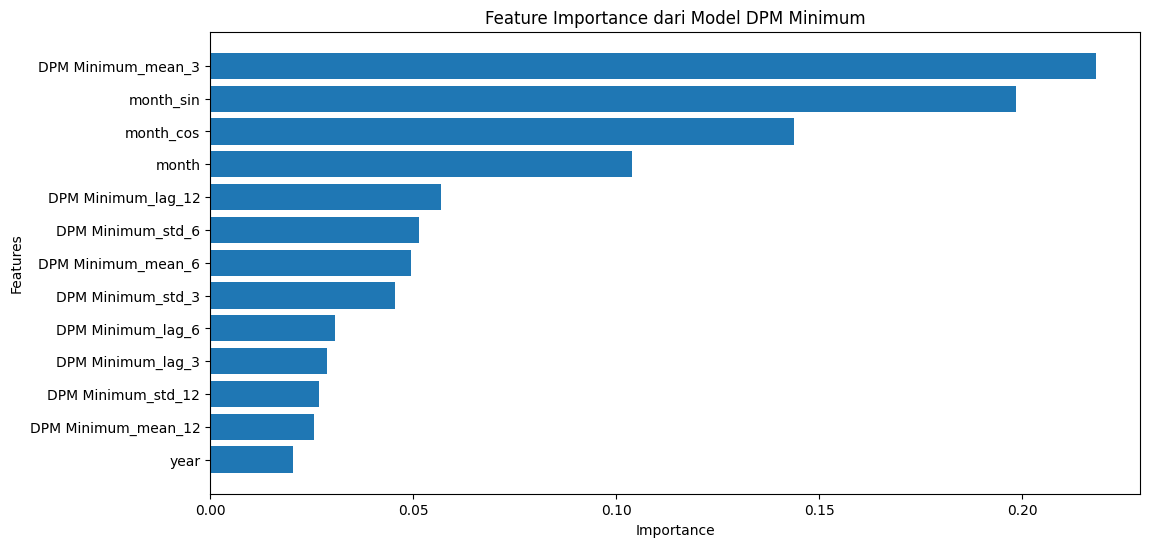

In [ ]:
# Visualisasi Feature Importance dari Model
feature_importance_data_min = pd.DataFrame({
    'feature': feature_names_min,
    'importance': importance_min
})

feature_importance_data_min = feature_importance_data_min.sort_values(by = 'importance', ascending = False)

plt.figure(figsize = (12, 6))
plt.barh(feature_importance_data_min['feature'], feature_importance_data_min['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance dari Model DPM Minimum')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Fungsi SMAPE
def symmetric_mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred))/2
    smape = np.mean(np.abs(y_true - y_pred)/denominator) * 100
    return smape

In [ ]:
# Evaluasi
mse_min = mean_squared_error(y_min, y_pred_min)
rmse_min = np.sqrt(mse_min)
smape_min = symmetric_mean_absolute_percentage_error(y_min, y_pred_min)

print("Evaluasi:")
print(f"MSE: {mse_min:.3f}")
print(f"RMSE: {rmse_min:.3f}")
print(f"SMAPE: {smape_min:.3f}%")

Evaluasi:
MSE: 15420623.193
RMSE: 3926.910
SMAPE: 31.670%


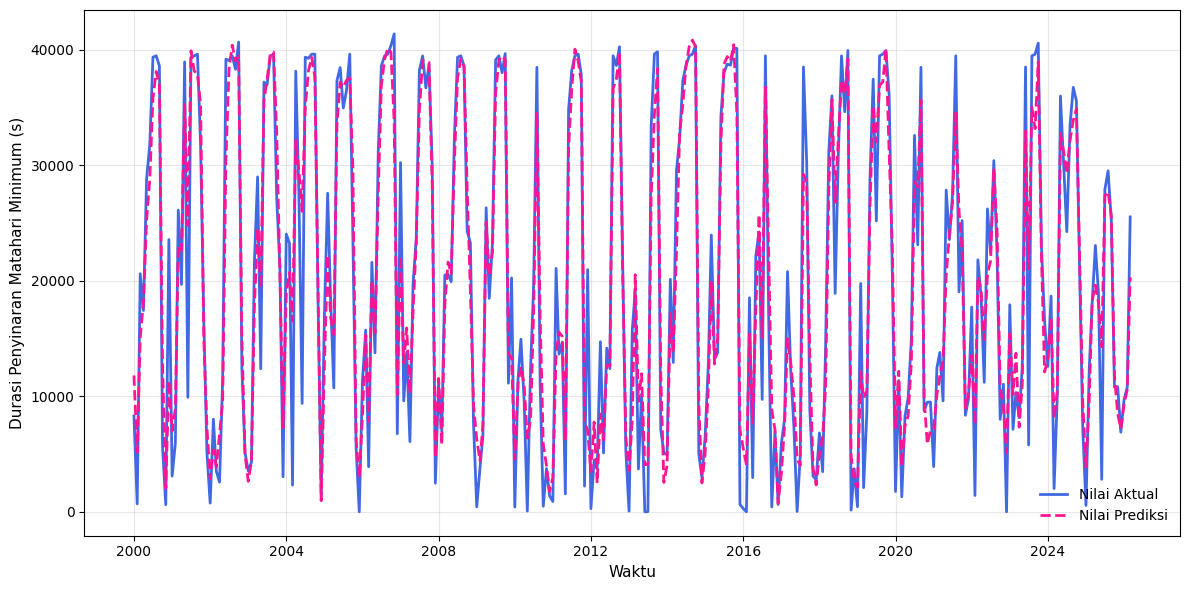

In [ ]:
# Visualisasi Data Aktual vs Prediksi
hasil_min = pd.DataFrame({
    'aktual': y_min,
    'prediksi': y_pred_min
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil_min.index,
    hasil_min['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil_min.index,
    hasil_min['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Durasi Penyinaran Matahari Minimum (s)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

In [ ]:
# Data Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual_min, prediksi_min in zip(y_min, y_pred_min):
    selisih_min = aktual_min - prediksi_min
    print(f"  {aktual_min:.3f}         {prediksi_min:.3f}            {selisih_min:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  8289.860         11799.445            -3509.585
  686.720         5145.545            -4458.825
  20599.380         15068.827            5530.554
  17417.370         18126.902            -709.533
  28800.000         25200.006            3599.994
  31795.200         28822.283            2972.916
  39332.820         35764.070            3568.750
  39458.800         38096.680            1362.121
  38588.180         37022.969            1565.211
  5636.370         12746.104            -7109.733
  615.430         2032.396            -1416.966
  23553.690         11324.588            12229.102
  3092.910         6987.137            -3894.227
  5933.420         8900.795            -2967.375
  26104.590         23016.035            3088.555
  19680.310         22609.801            -2929.490
  38925.200         35227.105            3698.094
  9904.110         24785.172            -14881.062
  39334.970         3

In [ ]:
# Fungsi untuk Peramalan
def quick_forecast_future(model, X_features, all_processed_data, target_name, n_months):

    predictions = []
    historical_features = X_features.columns.tolist()

    current_data = all_processed_data.copy()

    all_values = current_data[target_name].tolist()

    print(f"Data historis tersedia: {len(all_values)} bulan")
    print(f"Data terakhir: {all_values[-1]:.3f}")

    last_date = current_data.index[-1]
    forecast_dates = pd.date_range(
        start = last_date + pd.DateOffset(months = 1),
        periods = n_months,
        freq = 'MS'
    )

    print(f"Forecast periode: {forecast_dates[0].strftime('%B %Y')} - {forecast_dates[-1].strftime('%B %Y')}")

    for i in range(n_months):

        input_features = pd.DataFrame()

        forecast_date = forecast_dates[i]
        month = forecast_date.month
        year = forecast_date.year

        if 'year' in historical_features:
            input_features['year'] = [year]

        if 'month' in historical_features:
            input_features['month'] = [month]

        for lag in lag_features:
            col_name = f'{target_name}_lag_{lag}'
            if col_name in historical_features:
                if len(all_values) >= lag:
                    input_features[col_name] = [all_values[-lag]]
                else:
                    input_features[col_name] = [np.nan]

        for window in rolling_windows:
            col_name = f'{target_name}_mean_{window}'
            if col_name in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name] = [temp_df[target_name].iloc[-window:].mean()]
                else:
                    input_features[col_name] = [np.nan]

            col_name_std = f'{target_name}_std_{window}'
            if col_name_std in historical_features:
                if len(all_values) >= window:

                    temp_dates = pd.date_range(
                        start = current_data.index[0],
                        periods = len(all_values),
                        freq = 'MS'
                    )
                    temp_df = pd.DataFrame({target_name: all_values}, index = temp_dates)
                    input_features[col_name_std] = [temp_df[target_name].iloc[-window:].std()]
                else:
                    input_features[col_name_std] = [np.nan]

        input_features['month_sin'] = [np.sin(2 * np.pi * month / 12)]
        input_features['month_cos'] = [np.cos(2 * np.pi * month / 12)]

        for col in historical_features:
            if col not in input_features.columns:

                input_features[col] = [X_features[col].mean()]

        input_features = input_features[historical_features]

        pred = model.predict(input_features)[0]
        predictions.append(pred)

        all_values.append(pred)

    return predictions, forecast_dates

In [ ]:
# Melakukan Forecasting
pred_min_future, dates_min = quick_forecast_future(
        final_model_min,
        X_min,
        all_min_processed,
        'DPM Minimum',
        n_months = 9
    )
for date, pred in zip(dates_min, pred_min_future):
        print(f"  {date.strftime('%B %Y')}: {pred:.3f}")

Data historis tersedia: 315 bulan
Data terakhir: 25516.610
Forecast periode: April 2026 - December 2026
  April 2026: 18815.248
  May 2026: 16587.387
  June 2026: 20925.971
  July 2026: 19378.189
  August 2026: 21412.773
  September 2026: 19168.076
  October 2026: 15216.311
  November 2026: 11547.577
  December 2026: 11261.506


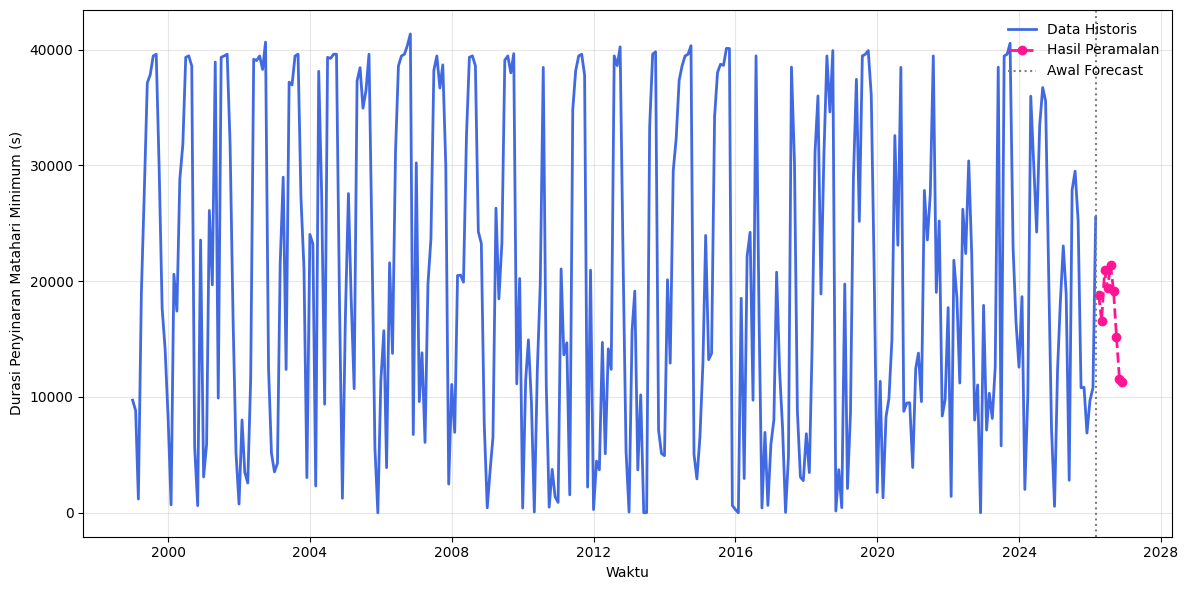

In [ ]:
# Visualisasi Hasil Peramalan
forecast_min = pd.DataFrame({
    'tanggal': dates_min,
    'prediksi': pred_min_future
})
forecast_min.set_index('tanggal', inplace = True)

historical_data_min = data_min[['DPM Minimum']].copy()
combined_min = pd.concat([historical_data_min, forecast_min.rename(columns = {'prediksi': 'DPM Minimum'})])

plt.figure(figsize = (12, 6))

plt.plot(
    historical_data_min.index,
    historical_data_min['DPM Minimum'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_min.index,
    forecast_min['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.axvline(
    x = historical_data_min.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Minimum (s)')

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

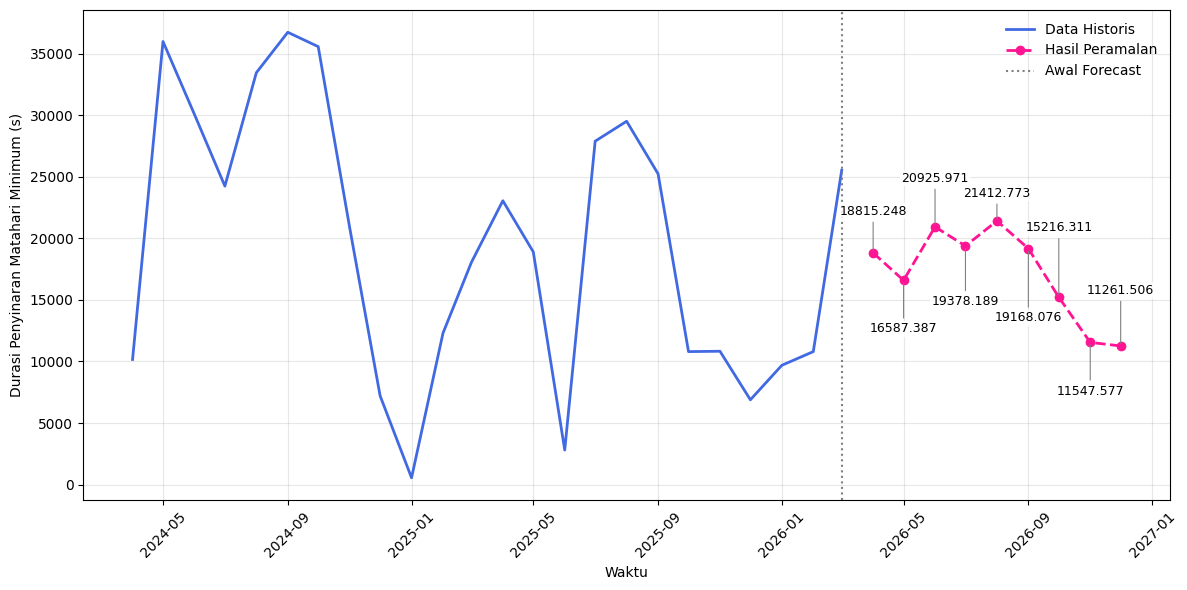

In [ ]:
# Visualisasi Hasil Peramalan
historical_tail_min = data_min[['DPM Minimum']].tail(24).copy()

forecast_min = pd.DataFrame({
    'tanggal': dates_min,
    'prediksi': pred_min_future
})
forecast_min.set_index('tanggal', inplace = True)

plt.figure(figsize = (12, 6))

plt.plot(
    historical_tail_min.index,
    historical_tail_min['DPM Minimum'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_min.index,
    forecast_min['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.axvline(
    x = historical_tail_min.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

offsets = [
    (0, 30),
    (0, -35),
    (0, 35),
    (0, -40),
    (0, 20),
    (0, -50),
    (0, 50),
    (0, -35),
    (0, 40)
]

for (x, y), (dx, dy) in zip(zip(forecast_min.index, forecast_min['prediksi']), offsets):
    plt.annotate(
        f'{y:.3f}',
        xy = (x, y),
        xytext = (dx, dy),
        textcoords = 'offset points',
        ha = 'center',
        va = 'center',
        fontsize = 9,
        bbox = dict(facecolor = 'white', alpha = 0.85, edgecolor = 'none', pad = 1.2),
        arrowprops = dict(
            arrowstyle = '-',
            color = 'gray',
            lw = 0.8
        )
    )

plt.xlabel('Waktu')
plt.ylabel('Durasi Penyinaran Matahari Minimum (s)')
plt.xticks(rotation = 45)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()